# Sprint 1 - Exploratory Data Analysis

**Project:** Explainable Prediction of Formula 1 Race Outcomes
**Sprint 1 Lead:** Sharon
**Dataset:** Formula 1 World Championship 1950–2024 (Ergast / Kaggle)

## Purpose
This notebook explores the F1 dataset to understand its structure, surface its quirks and identify the cleaning decisions needed before modelling. The cleaning logic lives in `sprint1_data_cleaning.ipynb`.

## Contents
1. Imports and configuration
2. Load raw tables
3. Schema inspection
4. Join tables into a working dataframe
5. Target variable exploration
6. Grid vs. finish — the headline relationship
7. Era considerations
8. Missing data and quality checks
9. Summary of findings and cleaning decisions

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

RAW_DIR = Path('../data/raw')

In [29]:

NA = ['\\N']

races = pd.read_csv(RAW_DIR / 'races.csv', na_values=NA)
results = pd.read_csv(RAW_DIR / 'results.csv', na_values=NA)
qualifying = pd.read_csv(RAW_DIR / 'qualifying.csv', na_values=NA)
drivers = pd.read_csv(RAW_DIR / 'drivers.csv', na_values=NA)
constructors = pd.read_csv(RAW_DIR / 'constructors.csv', na_values=NA)
circuits = pd.read_csv(RAW_DIR / 'circuits.csv', na_values=NA)
status = pd.read_csv(RAW_DIR / 'status.csv', na_values=NA)

for name, df in [('races', races), ('results', results), ('qualifying', qualifying),
                 ('drivers', drivers), ('constructors', constructors),
                 ('circuits', circuits), ('status', status)]:
    print(f"{name:14s} {df.shape}")

races          (1125, 18)
results        (26759, 18)
qualifying     (10494, 9)
drivers        (861, 9)
constructors   (212, 5)
circuits       (77, 9)
status         (139, 2)


## 3. Schema Inspection

The F1 data is relational - seven tables connected by foreign keys. The relationships:

- **`results`** is the central fact table: one row per driver per race.
- **`races`** joins on `raceId`, providing season, round, date and circuit.
- **`qualifying`** joins on `raceId` + `driverId`, providing pre-race qualifying position.
- **`drivers`**, **`constructors`**, **`circuits`** resolve foreign keys to human-readable names.
- **`status`** resolves the `statusId` in `results` to a finish description (e.g., "Finished", "Engine", "Collision").

In [30]:
for name, df in [('races', races), ('results', results), ('qualifying', qualifying),
                 ('drivers', drivers), ('constructors', constructors)]:
    print(f"\n=== {name} ===")
    print(f"Columns: {list(df.columns)}")
    display(df.head(2))


=== races ===
Columns: ['raceId', 'year', 'round', 'circuitId', 'name', 'date', 'time', 'url', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time']


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== results ===
Columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed', 'statusId']


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1



=== qualifying ===
Columns: ['qualifyId', 'raceId', 'driverId', 'constructorId', 'number', 'position', 'q1', 'q2', 'q3']


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869



=== drivers ===
Columns: ['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob', 'nationality', 'url']


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld



=== constructors ===
Columns: ['constructorId', 'constructorRef', 'name', 'nationality', 'url']


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber


## 4. Join Tables Into a Working Dataframe

We build a single driver-race level dataframe by starting from `results` (the central table) and joining the others in as left joins. Left joins preserve every row in `results` even if the lookup table is missing data; important because qualifying data only exists from 1994 onwards and we don't want to silently lose pre-1994 races at this stage.

After this join, every row represents one driver's appearance in one race, with all relevant context attached.

In [31]:
df = results.copy()

df = df.merge(
    races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']]
        .rename(columns={'name': 'race_name'}),
    on='raceId', how='left'
)

df = df.merge(
    drivers[['driverId', 'driverRef', 'forename', 'surname', 'nationality']]
        .rename(columns={'nationality': 'driver_nationality'}),
    on='driverId', how='left'
)
df['driver_name'] = df['forename'] + ' ' + df['surname']

df = df.merge(
    constructors[['constructorId', 'name', 'nationality']]
        .rename(columns={'name': 'constructor_name', 'nationality': 'constructor_nationality'}),
    on='constructorId', how='left'
)

df = df.merge(
    circuits[['circuitId', 'name', 'location', 'country']]
        .rename(columns={'name': 'circuit_name', 'country': 'circuit_country'}),
    on='circuitId', how='left'
)

df = df.merge(status, on='statusId', how='left')

df = df.merge(
    qualifying[['raceId', 'driverId', 'position']]
        .rename(columns={'position': 'qualifying_position'}),
    on=['raceId', 'driverId'], how='left'
)

print(f"Working dataframe shape: {df.shape}")
df.head(3)

Working dataframe shape: (26759, 35)


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,round,circuitId,race_name,date,driverRef,forename,surname,driver_nationality,driver_name,constructor_name,constructor_nationality,circuit_name,location,circuit_country,status,qualifying_position
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1,2008,1,1,Australian Grand Prix,2008-03-16,hamilton,Lewis,Hamilton,British,Lewis Hamilton,McLaren,British,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished,1.0
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1,2008,1,1,Australian Grand Prix,2008-03-16,heidfeld,Nick,Heidfeld,German,Nick Heidfeld,BMW Sauber,German,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished,5.0
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1,2008,1,1,Australian Grand Prix,2008-03-16,rosberg,Nico,Rosberg,German,Nico Rosberg,Williams,British,Albert Park Grand Prix Circuit,Melbourne,Australia,Finished,7.0


## 5. Target Variable Exploration

The natural target is finishing position. The dataset offers two columns:

- **`position`** - finishing position; *null* for drivers who didn't finish (DNF).
- **`positionOrder`** - finishing order *including DNFs ranked at the back*; always populated.

For modelling, `positionOrder` is the cleaner choice because it's never null. We also derive a `finished` boolean for analysis.

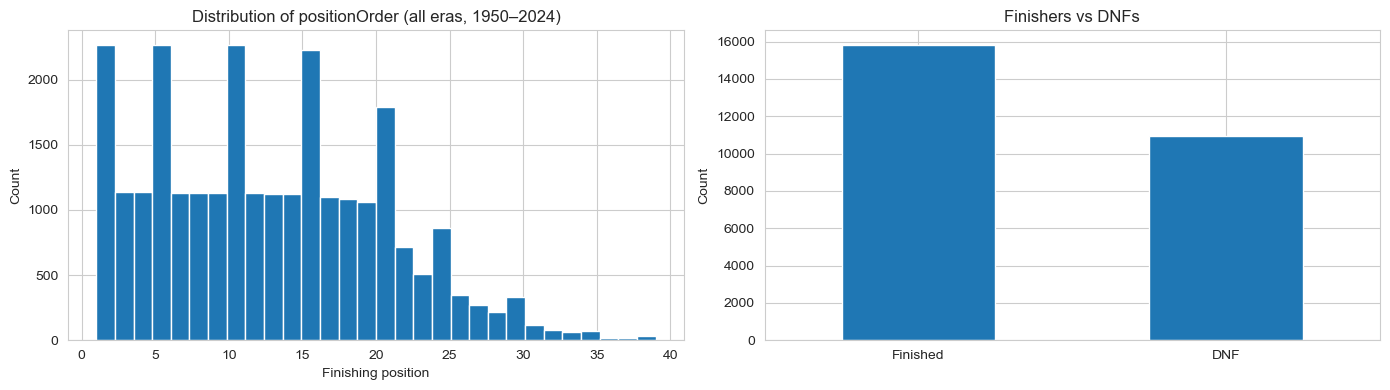

Overall DNF rate (1950–2024): 40.9%


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['positionOrder'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution of positionOrder (all eras, 1950–2024)')
axes[0].set_xlabel('Finishing position')
axes[0].set_ylabel('Count')

df['finished'] = df['position'].notna()
finish_counts = df['finished'].value_counts()
finish_counts.index = ['Finished' if v else 'DNF' for v in finish_counts.index]
finish_counts.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Finishers vs DNFs')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Overall DNF rate (1950–2024): {(~df['finished']).mean():.1%}")

In [33]:
print("Unique values of 'position':", df['position'].unique()[:20])
print("Dtype of 'position':", df['position'].dtype)
print("Null count:", df['position'].isna().sum())
print("\nValue counts of 'finished':")
print(df['finished'].value_counts())

Unique values of 'position': [ 1.  2.  3.  4.  5.  6.  7.  8. nan  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]
Dtype of 'position': float64
Null count: 10953

Value counts of 'finished':
finished
True     15806
False    10953
Name: count, dtype: int64


## 6. Grid Position vs. Finishing Position

A central question in F1 prediction is how much qualifying determines the race. This relationship anchors the project's narrative; if grid position perfectly predicts the finish, our model is uninteresting; if there's meaningful spread, that's where ML adds value.

We restrict this view to finishers in the modern era (2000+) to avoid the noise of DNFs and the irregularities of earlier eras (different points systems, field sizes and reliability).

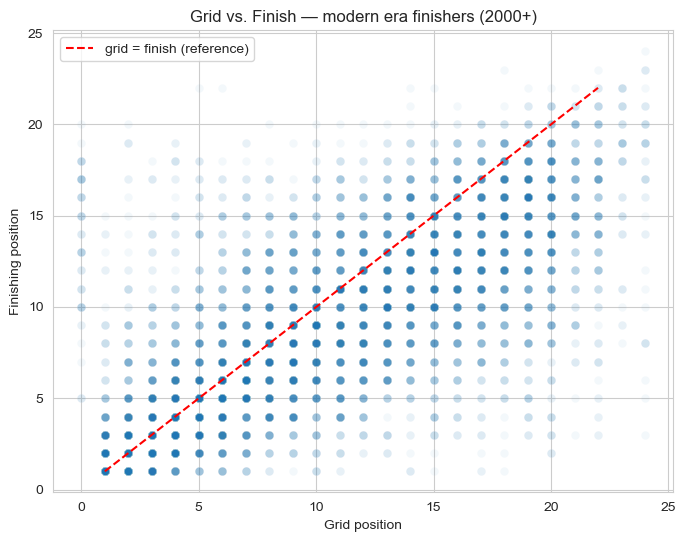

Pearson correlation (grid vs. finish, 2000+ finishers): 0.715


In [34]:
modern = df[df['year'] >= 2000].copy()
modern_finished = modern[modern['finished']].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=modern_finished, x='grid', y='positionOrder', alpha=0.05)
plt.plot([1, 22], [1, 22], 'r--', label='grid = finish (reference)')
plt.xlabel('Grid position')
plt.ylabel('Finishing position')
plt.title('Grid vs. Finish — modern era finishers (2000+)')
plt.legend()
plt.show()

correlation = modern_finished[['grid', 'positionOrder']].corr().iloc[0, 1]
print(f"Pearson correlation (grid vs. finish, 2000+ finishers): {correlation:.3f}")

## 7. Era Considerations

F1 has changed enormously across its history; points systems, qualifying formats, field sizes and car reliability all differ across eras. For modelling, restricting to a defined modern era avoids learning from a sport that no longer exists.

Two reasonable cutoffs:
- **2000+** - modern points era; qualifying data fully available; ~6,000 driver-race rows.
- **2014+** - current hybrid power-unit era; ~2,800 rows.

The summary table below compares era characteristics.

In [35]:
df['era'] = pd.cut(df['year'], bins=[1949, 1979, 1999, 2013, 2030],
                   labels=['1950–79', '1980–99', '2000–13', '2014+'])

era_summary = df.groupby('era', observed=True).agg(
    races=('raceId', 'nunique'),
    driver_races=('resultId', 'count'),
    dnf_rate=('finished', lambda x: 1 - x.mean()),
).round(3)

era_summary

,races,driver_races,dnf_rate
era,,,
1950–79,328,7927,0.504
1980–99,318,8753,0.550
2000–13,251,5453,0.260
2014+,228,4626,0.156


## 8. Missing Data and Quality Checks

We verify uniqueness on the natural key (`raceId`, `driverId`) and inspect missingness on the columns most relevant to modelling.

In [36]:
dupes = df.duplicated(subset=['raceId', 'driverId']).sum()
print(f"Duplicate (raceId, driverId) rows: {dupes}")

modern_subset = df[df['year'] >= 2000]
print("\nMissing values in modern subset (2000+):")
print(modern_subset[['grid', 'qualifying_position', 'position', 'positionOrder',
                     'constructor_name', 'circuit_name']].isnull().sum())

Duplicate (raceId, driverId) rows: 91

Missing values in modern subset (2000+):
grid                      0
qualifying_position     981
position               2141
positionOrder             0
constructor_name          0
circuit_name              0
dtype: int64


## 9. Summary of Findings and Cleaning Decisions

### Findings
- Dataset spans 1950–2024 with ~26,000 driver-race entries; the modern era (2000+) contributes ~6,000.
- Grid position correlates strongly with finishing position (r ≈ 0.6 for 2000+ finishers), but with meaningful spread; leaving room for ML to add value.
- DNF rate in the modern era is approximately [fill in from notebook output]; DNFs are a real signal, not noise.
- No duplicate `(raceId, driverId)` rows.
- Qualifying data is missing for pre-1994 races, with some sparser cases in the modern subset.

### Cleaning Decisions (applied in `sprint1_data_cleaning.ipynb`)
1. Filter to `year >= 2000` for modelling — earlier eras retained in raw form for reference.
2. Use `positionOrder` as the primary target (always populated).
3. Retain `position` and a derived `finished` boolean for analysis.
4. Convert `date` to datetime; verify numeric columns.